## PREPARACION DE DATOS

In [1]:
import pandas as pd

# Ruta del archivo
archivo = r"C:\Users\preci\OneDrive\02 TyF Nuevo\01 Diario\ANALISIS_PRECIOS_VS\MARGENES..xlsx"

# Obtener todas las hojas del Excel
xls = pd.ExcelFile(archivo)

# Lista para guardar cada hoja ya procesada
dataframes = []

# Recorrer cada hoja
for hoja in xls.sheet_names:
    df = pd.read_excel(
        archivo,
        sheet_name=hoja,
        usecols="A:H",      # Columnas A a H
        nrows=600           # Hasta la fila 500
    )
    
    # Agregar columna con el nombre de la hoja (opcional pero útil)
    df["HOJA"] = hoja
    
    dataframes.append(df)

# Unir todas las hojas en un solo DataFrame
base_concentrada = pd.concat(dataframes, ignore_index=True)

# Calcular Margen Bruto por tipo de combustible
base_concentrada["Diesel MB"] = base_concentrada["D"] * base_concentrada["D LTS"]
base_concentrada["Premium MB"] = base_concentrada["P"] * base_concentrada["P LTS"]
base_concentrada["Regular MB"] = base_concentrada["R"] * base_concentrada["R LTS"]

BD=base_concentrada
# Ver resultado



C:\Users\preci\AppData\Local\Temp\ipykernel_15832\4177480283.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_concentrada = pd.concat(dataframes, ignore_index=True)


## MARGENES UNITARIOS Y POR VOLUMEN

### Funciones auxiliares

In [2]:
import matplotlib.pyplot as plt

def margen_brutos(BD, estacion):
    df = BD[BD["ESTACION"] == estacion].copy()
    df = df.sort_values("FECHA")

    if df.empty:
        print("No hay datos para esa estación")
        return

    combustibles = {
        "Diesel MB": {"color": "black", "titulo": "Diesel - Margen Bruto"},
        "Premium MB": {"color": "red", "titulo": "Premium - Margen Bruto"},
        "Regular MB": {"color": "blue", "titulo": "Regular - Margen Bruto"}
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"Márgenes brutos - Estación {estacion}", fontsize=16)

    for ax, (col, cfg) in zip(axes, combustibles.items()):
        serie = df[col]

        promedio = serie.mean()
        maximo = serie.max()
        minimo = serie.min()
        ultimo_valor = serie.iloc[-1]
        ultima_fecha = df["FECHA"].iloc[-1]

        ax.plot(df["FECHA"], serie, color=cfg["color"], linewidth=2)

        ax.axhline(promedio, linestyle="--", alpha=0.7, label=f"Promedio: {promedio:,.0f}")
        ax.axhline(maximo, linestyle="--", alpha=0.7, label=f"Máx: {maximo:,.0f}")
        ax.axhline(minimo, linestyle="--", alpha=0.7, label=f"Mín: {minimo:,.0f}")

        ax.scatter(ultima_fecha, ultimo_valor, color=cfg["color"], zorder=5)
        ax.annotate(
            f"{ultimo_valor:,.0f}",
            (ultima_fecha, ultimo_valor),
            textcoords="offset points",
            xytext=(8, 5),
            fontsize=9,
            color=cfg["color"]
        )

        ax.set_title(cfg["titulo"])
        ax.set_xlabel("Fecha")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [3]:
import matplotlib.pyplot as plt

def margen_u(BD, estacion):
    df = BD[BD["ESTACION"] == estacion].copy()
    df = df.sort_values("FECHA")

    if df.empty:
        print("No hay datos para esa estación")
        return

    combustibles = {
        "D": {"color": "black", "titulo": "Diesel - Margen Unitario"},
        "P": {"color": "red", "titulo": "Premium - Margen Unitario"},
        "R": {"color": "blue", "titulo": "Regular - Margen Unitario"}
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"Márgenes unitarios - Estación {estacion}", fontsize=16)

    for ax, (col, cfg) in zip(axes, combustibles.items()):
        serie = df[col]

        promedio = serie.mean()
        maximo = serie.max()
        minimo = serie.min()
        ultimo_valor = serie.iloc[-1]
        ultima_fecha = df["FECHA"].iloc[-1]

        ax.plot(df["FECHA"], serie, color=cfg["color"], linewidth=2)

        ax.axhline(promedio, linestyle="--", alpha=0.7, label=f"Promedio: {promedio:.2f}")
        ax.axhline(maximo, linestyle="--", alpha=0.7, label=f"Máx: {maximo:.2f}")
        ax.axhline(minimo, linestyle="--", alpha=0.7, label=f"Mín: {minimo:.2f}")

        ax.scatter(ultima_fecha, ultimo_valor, color=cfg["color"], zorder=5)
        ax.annotate(
            f"{ultimo_valor:.2f}",
            (ultima_fecha, ultimo_valor),
            textcoords="offset points",
            xytext=(8, 5),
            fontsize=9,
            color=cfg["color"]
        )

        ax.set_title(cfg["titulo"])
        ax.set_xlabel("Fecha")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



### Graficas

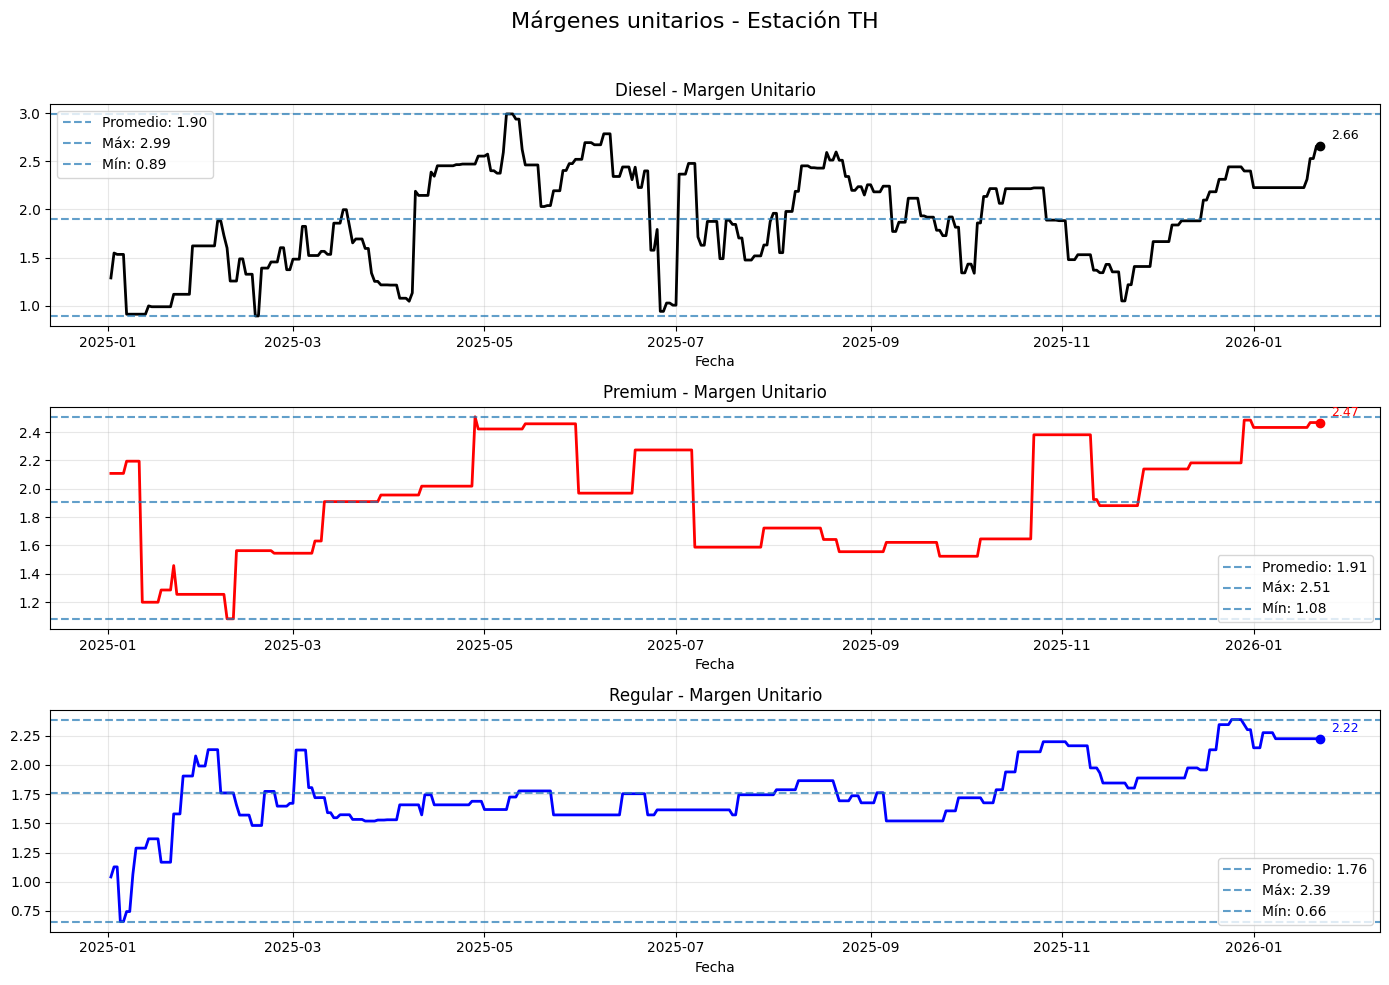

In [8]:
a='TH'
margen_u(BD, a)

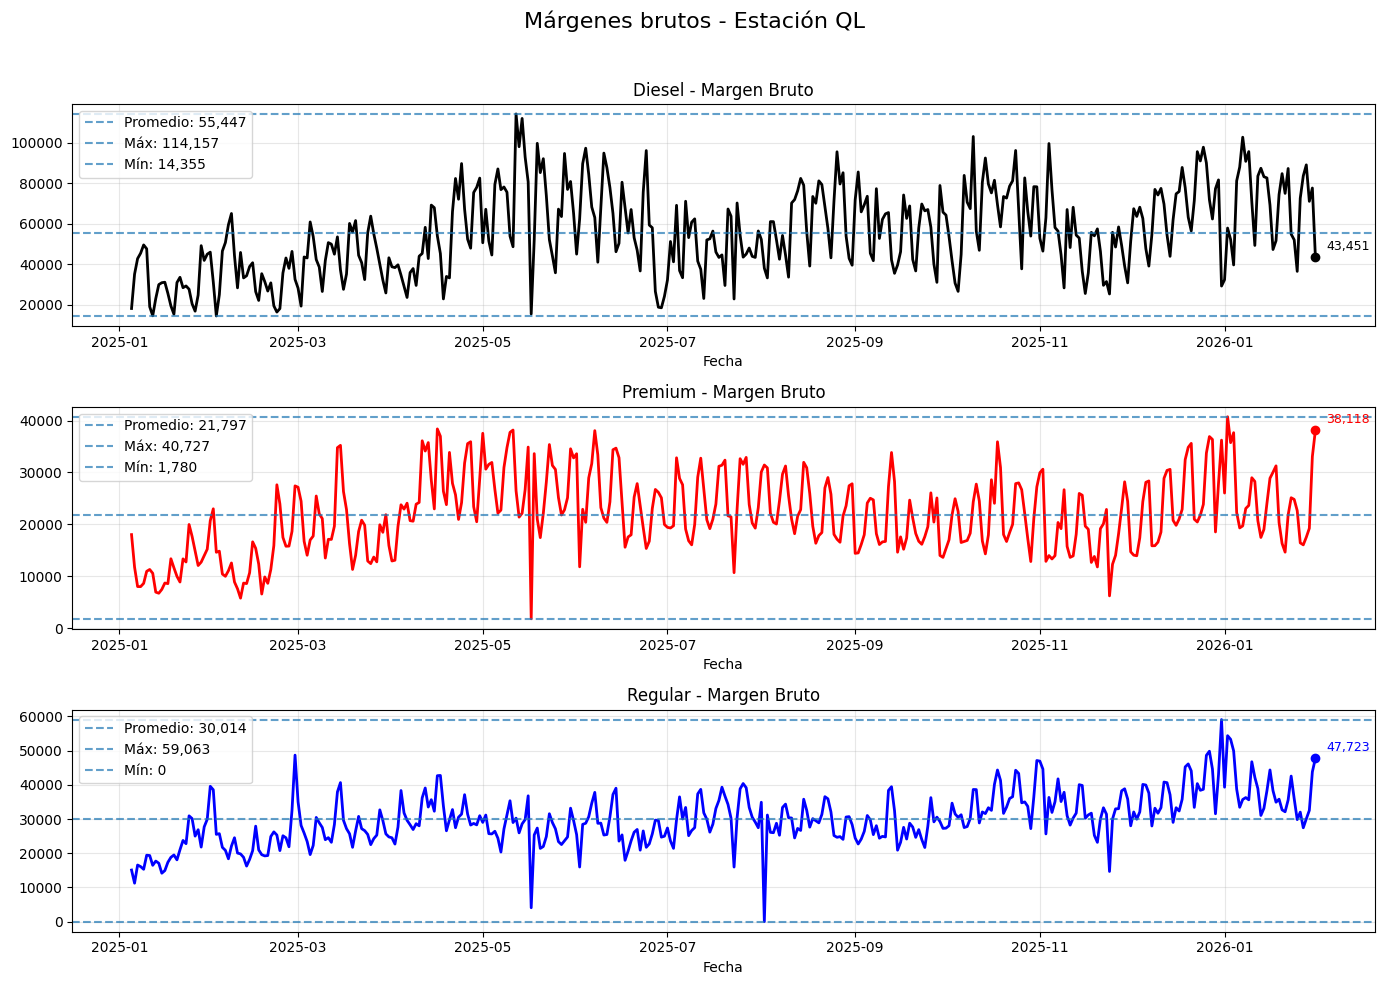

In [5]:
margen_brutos(BD,a)